In [1]:
pip install "gymnasium[mujoco]" stable-baselines3 pandas matplotlib imageio imageio-ffmpeg

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from stable_baselines3 import PPO, SAC, TD3
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise

warnings.filterwarnings("ignore")

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

TOTAL_TIMESTEPS = 100_000
EVALUATION_INTERVAL = 10_000
CHECKPOINT_EVAL_EPISODES = 10
FINAL_EVAL_EPISODES = 20

# Use the longer episode duration from the lab code
MAX_EPISODE_STEPS = 300

# Success means a final planar object-to-goal distance of 0.05 m or less
SUCCESS_THRESHOLD = 0.05

RESULTS_DIR = "pusher_results_300_default_reward"
MODELS_DIR = os.path.join(RESULTS_DIR, "models")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Experiment configuration completed.")

Experiment configuration completed.


In [4]:
def make_training_env(seed):
    env = gym.make(
        "Pusher-v5",
        max_episode_steps=MAX_EPISODE_STEPS,
        render_mode="human"
    )
    env = Monitor(env)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env


def make_evaluation_env():
    env = gym.make("Pusher-v5",max_episode_steps=MAX_EPISODE_STEPS)
    return env

In [6]:
def extract_positions(observation):
    fingertip_position = observation[14:17]
    object_position = observation[17:20]
    goal_position = observation[20:23]

    return fingertip_position, object_position, goal_position

In [7]:
def calculate_planar_distance(position_1, position_2):
    """
    Calculate the XY planar distance between two positions.
    """
    return float(np.linalg.norm(position_1[:2] - position_2[:2]))

def calculate_3d_distance(position_1, position_2):
    """
    Calculate the full 3D distance between two positions.
    """
    return float(np.linalg.norm(position_1 - position_2))

In [8]:
def run_evaluation_episode(model, env, seed):
    observation, info = env.reset(seed=seed)

    terminated = False
    truncated = False
    episode_return = 0.0
    total_control_effort = 0.0
    total_fingertip_object_distance = 0.0
    number_of_steps = 0

    while not (terminated or truncated):

        action, _ = model.predict(observation,deterministic=True)
        observation, reward, terminated, truncated, info = env.step(action)

        episode_return += float(reward)
        total_control_effort += float(np.sum(np.square(action)))
        fingertip_position, object_position, goal_position = (extract_positions(observation))
        # Accumulate fingertip-to-object distance at every step
        total_fingertip_object_distance += calculate_3d_distance(fingertip_position,object_position)

        number_of_steps += 1
    # Final object-to-goal distance is measured at the end
    fingertip_position, object_position, goal_position = (extract_positions(observation))
    final_object_goal_distance = calculate_planar_distance(object_position,goal_position)
    mean_fingertip_object_distance = (total_fingertip_object_distance /max(number_of_steps, 1))
    mean_control_effort = (total_control_effort /max(number_of_steps, 1))
    success = int(final_object_goal_distance <= SUCCESS_THRESHOLD)
    return {
        "return": episode_return,
        "object_goal_distance": final_object_goal_distance,
        "success": success,
        "fingertip_object_distance": mean_fingertip_object_distance,
        "control_effort": mean_control_effort,
        "episode_steps": number_of_steps
    }

In [9]:
def create_model(algorithm_name, env, seed):

    if algorithm_name == "PPO":
        model = PPO(
            policy="MlpPolicy",
            env=env,
            learning_rate=3e-4,
            n_steps=2_000,
            batch_size=100,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            ent_coef=0.01,
            policy_kwargs=dict(net_arch=[256, 256],activation_fn=torch.nn.ReLU),
            verbose=0,
            seed=seed
        )

    elif algorithm_name == "SAC":
        model = SAC(
            policy="MlpPolicy",
            env=env,
            learning_rate=3e-4,
            buffer_size=100_000,
            learning_starts=1_000,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            policy_kwargs=dict(net_arch=[256, 256],activation_fn=torch.nn.ReLU),
            verbose=0,
            seed=seed
        )

    elif algorithm_name == "TD3":
        number_of_actions = env.action_space.shape[-1]
        action_noise = NormalActionNoise(
            mean=np.zeros(number_of_actions),
            sigma=0.2 * np.ones(number_of_actions)
        )
        model = TD3(
            policy="MlpPolicy",
            env=env,
            learning_rate=1e-3,
            buffer_size=100_000,
            learning_starts=1_000,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            action_noise=action_noise,
            policy_kwargs=dict(net_arch=[256, 256],activation_fn=torch.nn.ReLU),
            verbose=0,
            seed=seed
        )
    return model

In [10]:
def evaluate_model(model,number_of_episodes,seed_offset):
    env = make_evaluation_env()
    episode_results = []

    for episode in range(number_of_episodes):
        episode_seed = seed_offset + episode
        result = run_evaluation_episode(model=model,env=env,seed=episode_seed)
        result["episode"] = episode + 1
        episode_results.append(result)
    env.close()
    episodes_df = pd.DataFrame(episode_results)
    summary = {
        "mean_return": episodes_df["return"].mean(),
        "std_return": episodes_df["return"].std(),
        "mean_object_goal_distance":episodes_df["object_goal_distance"].mean(),
        "std_object_goal_distance":episodes_df["object_goal_distance"].std(),
        "success_rate":episodes_df["success"].mean() * 100,
        "mean_fingertip_object_distance":episodes_df["fingertip_object_distance"].mean(),
        "std_fingertip_object_distance":episodes_df["fingertip_object_distance"].std(),
        "mean_control_effort": episodes_df["control_effort"].mean(),
        "std_control_effort":episodes_df["control_effort"].std()
    }

    return summary, episodes_df

In [11]:
def train_and_evaluate_algorithm(algorithm_name):
    print(f"\n{'=' * 55}")
    print(f"Training {algorithm_name}")
    print(f"{'=' * 55}")

    training_env = make_training_env(42)

    model = create_model(algorithm_name=algorithm_name,env=training_env,seed=42)
    checkpoint_results = []
    # Evaluate the untrained model at step 0
    initial_summary, _ = evaluate_model(model=model,number_of_episodes=CHECKPOINT_EVAL_EPISODES,seed_offset=10_000)
    initial_summary["algorithm"] = algorithm_name
    initial_summary["steps"] = 0
    checkpoint_results.append(initial_summary)

    print(f"{algorithm_name} | Step 0 | " f"Return: {initial_summary['mean_return']:.2f}")

    # Train and evaluate every 10,000 interactions
    for requested_steps in range(EVALUATION_INTERVAL,TOTAL_TIMESTEPS + 1,EVALUATION_INTERVAL):
        model.learn(total_timesteps=EVALUATION_INTERVAL,reset_num_timesteps=False,progress_bar=False)
        # Read the actual number of training interactions
        actual_steps = model.num_timesteps
        checkpoint_summary, _ = evaluate_model(model=model,
            number_of_episodes=CHECKPOINT_EVAL_EPISODES,seed_offset=10_000)

        checkpoint_summary["algorithm"] = algorithm_name
        checkpoint_summary["steps"] = actual_steps
        checkpoint_results.append(checkpoint_summary)
        # Save the model at the current checkpoint
        checkpoint_path = os.path.join(MODELS_DIR, f"{algorithm_name.lower()}_{actual_steps}_steps")
        model.save(checkpoint_path)
        print(
            f"{algorithm_name} | "
            f"Step {actual_steps:,} | "
            f"Return: {checkpoint_summary['mean_return']:.2f} | "
            f"Distance: "
            f"{checkpoint_summary['mean_object_goal_distance']:.4f} | "
            f"Success: "
            f"{checkpoint_summary['success_rate']:.1f}% | "
            f"Effort: "
            f"{checkpoint_summary['mean_control_effort']:.4f}"
        )

    # Save the final trained model
    final_model_path = os.path.join(MODELS_DIR,f"{algorithm_name.lower()}_final_model")
    model.save(final_model_path)
    print(f"{algorithm_name} actual training interactions: " f"{model.num_timesteps:,}")

    training_env.close()
    checkpoint_df = pd.DataFrame(checkpoint_results)
    return model, checkpoint_df

In [12]:
trained_models = {}
algorithms = ["PPO", "SAC", "TD3"]

In [13]:
ppo_model, ppo_learning_results = train_and_evaluate_algorithm("PPO")
trained_models["PPO"] = ppo_model
ppo_learning_results.to_csv(os.path.join(RESULTS_DIR, "ppo_learning_results.csv"),index=False)
ppo_learning_results


Training PPO
PPO | Step 0 | Return: -166.53
PPO | Step 10,000 | Return: -130.95 | Distance: 0.2108 | Success: 0.0% | Effort: 0.0805
PPO | Step 20,000 | Return: -121.19 | Distance: 0.2228 | Success: 0.0% | Effort: 0.2390
PPO | Step 30,000 | Return: -107.35 | Distance: 0.2075 | Success: 0.0% | Effort: 0.1326
PPO | Step 40,000 | Return: -108.55 | Distance: 0.2257 | Success: 0.0% | Effort: 0.1057
PPO | Step 50,000 | Return: -103.23 | Distance: 0.2256 | Success: 0.0% | Effort: 0.0595
PPO | Step 60,000 | Return: -108.85 | Distance: 0.2350 | Success: 0.0% | Effort: 0.0858
PPO | Step 70,000 | Return: -104.46 | Distance: 0.2135 | Success: 0.0% | Effort: 0.0740
PPO | Step 80,000 | Return: -105.11 | Distance: 0.2375 | Success: 0.0% | Effort: 0.0653
PPO | Step 90,000 | Return: -100.00 | Distance: 0.2509 | Success: 0.0% | Effort: 0.0601
PPO | Step 100,000 | Return: -100.80 | Distance: 0.2637 | Success: 0.0% | Effort: 0.0795
PPO actual training interactions: 100,000


,mean_return,std_return,mean_object_goal_distance,std_object_goal_distance,success_rate,mean_fingertip_object_distance,std_fingertip_object_distance,mean_control_effort,std_control_effort,algorithm,steps
0,-166.531847,14.213776,0.211046,0.034424,0.0,0.677100,0.094310,0.000005,2.641558e-07,PPO,0
1,-130.948910,8.594554,0.210810,0.035187,0.0,0.423749,0.013649,0.080547,4.787126e-03,PPO,10000
2,-121.187262,10.956551,0.222798,0.028679,0.0,0.317335,0.058653,0.238960,6.269600e-03,PPO,20000
3,-107.353083,12.338460,0.207476,0.048128,0.0,0.260487,0.056776,0.132602,1.115196e-02,PPO,30000
4,-108.548860,11.477398,0.225682,0.052837,0.0,0.249346,0.079916,0.105709,5.474756e-03,PPO,40000
5,-103.234045,11.681608,0.225588,0.046488,0.0,0.225894,0.061763,0.059545,3.031086e-03,PPO,50000
6,-108.850378,14.458104,0.234971,0.074541,0.0,0.239528,0.074610,0.085769,8.498548e-03,PPO,60000
7,-104.462922,16.882920,0.213470,0.049974,0.0,0.245216,0.076941,0.074010,5.692460e-03,PPO,70000
8,-105.111246,15.110830,0.237481,0.037805,0.0,0.217554,0.067822,0.065323,2.110299e-03,PPO,80000
9,-100.004589,12.658082,0.250860,0.071474,0.0,0.170787,0.046768,0.060122,2.035404e-03,PPO,90000


In [14]:
sac_model, sac_learning_results = train_and_evaluate_algorithm("SAC")
trained_models["SAC"] = sac_model
sac_learning_results.to_csv(os.path.join(RESULTS_DIR, "sac_learning_results.csv"),index=False)
sac_learning_results


Training SAC
SAC | Step 0 | Return: -184.43
SAC | Step 10,000 | Return: -112.39 | Distance: 0.2111 | Success: 0.0% | Effort: 0.1046
SAC | Step 20,000 | Return: -100.99 | Distance: 0.2242 | Success: 0.0% | Effort: 0.0968
SAC | Step 30,000 | Return: -103.63 | Distance: 0.2297 | Success: 0.0% | Effort: 0.2992
SAC | Step 40,000 | Return: -108.79 | Distance: 0.2656 | Success: 0.0% | Effort: 0.2844
SAC | Step 50,000 | Return: -175.75 | Distance: 0.2235 | Success: 0.0% | Effort: 2.0325
SAC | Step 60,000 | Return: -87.25 | Distance: 0.1876 | Success: 0.0% | Effort: 0.1477
SAC | Step 70,000 | Return: -99.28 | Distance: 0.2280 | Success: 0.0% | Effort: 0.2716
SAC | Step 80,000 | Return: -93.88 | Distance: 0.1773 | Success: 0.0% | Effort: 0.3282
SAC | Step 90,000 | Return: -90.01 | Distance: 0.1735 | Success: 0.0% | Effort: 0.1406
SAC | Step 100,000 | Return: -78.24 | Distance: 0.1435 | Success: 40.0% | Effort: 0.1563
SAC actual training interactions: 100,000


,mean_return,std_return,mean_object_goal_distance,std_object_goal_distance,success_rate,mean_fingertip_object_distance,std_fingertip_object_distance,mean_control_effort,std_control_effort,algorithm,steps
0,-184.432023,8.526610,0.211046,0.034424,0.0,0.763039,0.055561,0.166985,0.007573,SAC,0
1,-112.389022,11.068144,0.211095,0.034520,0.0,0.295161,0.069492,0.104558,0.036766,SAC,10000
2,-100.988550,9.293713,0.224193,0.038034,0.0,0.202762,0.047013,0.096761,0.015396,SAC,20000
3,-103.629603,22.989934,0.229710,0.129414,0.0,0.182577,0.039756,0.299231,0.096746,SAC,30000
4,-108.790723,23.247965,0.265586,0.101783,0.0,0.167786,0.039170,0.284366,0.167639,SAC,40000
5,-175.752611,63.241992,0.223471,0.039802,0.0,0.313064,0.115866,2.032500,1.437125,SAC,50000
6,-87.252749,10.676655,0.187617,0.050510,0.0,0.151211,0.025975,0.147657,0.051628,SAC,60000
7,-99.280218,24.005742,0.227962,0.110199,0.0,0.164317,0.028558,0.271630,0.168756,SAC,70000
8,-93.881393,22.873095,0.177280,0.064690,0.0,0.153766,0.053511,0.328181,0.244961,SAC,80000
9,-90.009570,15.385818,0.173457,0.067585,0.0,0.188594,0.050036,0.140627,0.124409,SAC,90000


In [15]:
td3_model, td3_learning_results = train_and_evaluate_algorithm("TD3")

trained_models["TD3"] = td3_model
td3_learning_results.to_csv(os.path.join(RESULTS_DIR, "td3_learning_results.csv"),index=False)
td3_learning_results


Training TD3
TD3 | Step 0 | Return: -184.43
TD3 | Step 10,000 | Return: -103.18 | Distance: 0.2415 | Success: 0.0% | Effort: 0.1932
TD3 | Step 20,000 | Return: -107.30 | Distance: 0.2827 | Success: 0.0% | Effort: 0.1953
TD3 | Step 30,000 | Return: -98.81 | Distance: 0.3181 | Success: 0.0% | Effort: 0.1517
TD3 | Step 40,000 | Return: -96.01 | Distance: 0.2377 | Success: 0.0% | Effort: 0.1675
TD3 | Step 50,000 | Return: -79.37 | Distance: 0.1879 | Success: 0.0% | Effort: 0.1326
TD3 | Step 60,000 | Return: -66.70 | Distance: 0.0789 | Success: 60.0% | Effort: 0.1284
TD3 | Step 70,000 | Return: -68.94 | Distance: 0.1153 | Success: 50.0% | Effort: 0.0985
TD3 | Step 80,000 | Return: -59.67 | Distance: 0.0739 | Success: 60.0% | Effort: 0.0821
TD3 | Step 90,000 | Return: -53.65 | Distance: 0.0763 | Success: 0.0% | Effort: 0.1157
TD3 | Step 100,000 | Return: -56.77 | Distance: 0.0754 | Success: 70.0% | Effort: 0.1073
TD3 actual training interactions: 100,000


,mean_return,std_return,mean_object_goal_distance,std_object_goal_distance,success_rate,mean_fingertip_object_distance,std_fingertip_object_distance,mean_control_effort,std_control_effort,algorithm,steps
0,-184.432023,8.526610,0.211046,0.034424,0.0,0.763039,0.055561,0.166985,0.007573,TD3,0
1,-103.175982,18.550193,0.241533,0.090254,0.0,0.202909,0.032626,0.193222,0.006690,TD3,10000
2,-107.299947,33.362989,0.282678,0.127830,0.0,0.150445,0.044341,0.195258,0.052781,TD3,20000
3,-98.811880,15.186492,0.318088,0.063635,0.0,0.107395,0.011679,0.151707,0.085948,TD3,30000
4,-96.008173,26.438462,0.237719,0.107310,0.0,0.143151,0.053358,0.167487,0.040528,TD3,40000
5,-79.367663,9.574528,0.187912,0.033327,0.0,0.109696,0.011882,0.132575,0.031851,TD3,50000
6,-66.699882,21.577029,0.078876,0.071174,60.0,0.130263,0.054685,0.128351,0.026334,TD3,60000
7,-68.941816,28.179587,0.115267,0.099482,50.0,0.141508,0.052806,0.098515,0.018160,TD3,70000
8,-59.668971,24.639976,0.073867,0.087047,60.0,0.131769,0.044878,0.082106,0.021035,TD3,80000
9,-53.652305,7.245459,0.076302,0.005602,0.0,0.108578,0.014924,0.115718,0.033513,TD3,90000


In [16]:
learning_results_df = pd.concat([ppo_learning_results,sac_learning_results,td3_learning_results],ignore_index=True)
learning_results_df.to_csv(os.path.join(RESULTS_DIR,"learning_curve_results.csv"),index=False)
learning_results_df

,mean_return,std_return,mean_object_goal_distance,std_object_goal_distance,success_rate,mean_fingertip_object_distance,std_fingertip_object_distance,mean_control_effort,std_control_effort,algorithm,steps
0,-166.531847,14.213776,0.211046,0.034424,0.0,0.677100,0.094310,0.000005,2.641558e-07,PPO,0
1,-130.948910,8.594554,0.210810,0.035187,0.0,0.423749,0.013649,0.080547,4.787126e-03,PPO,10000
2,-121.187262,10.956551,0.222798,0.028679,0.0,0.317335,0.058653,0.238960,6.269600e-03,PPO,20000
3,-107.353083,12.338460,0.207476,0.048128,0.0,0.260487,0.056776,0.132602,1.115196e-02,PPO,30000
4,-108.548860,11.477398,0.225682,0.052837,0.0,0.249346,0.079916,0.105709,5.474756e-03,PPO,40000
5,-103.234045,11.681608,0.225588,0.046488,0.0,0.225894,0.061763,0.059545,3.031086e-03,PPO,50000
6,-108.850378,14.458104,0.234971,0.074541,0.0,0.239528,0.074610,0.085769,8.498548e-03,PPO,60000
7,-104.462922,16.882920,0.213470,0.049974,0.0,0.245216,0.076941,0.074010,5.692460e-03,PPO,70000
8,-105.111246,15.110830,0.237481,0.037805,0.0,0.217554,0.067822,0.065323,2.110299e-03,PPO,80000
9,-100.004589,12.658082,0.250860,0.071474,0.0,0.170787,0.046768,0.060122,2.035404e-03,PPO,90000


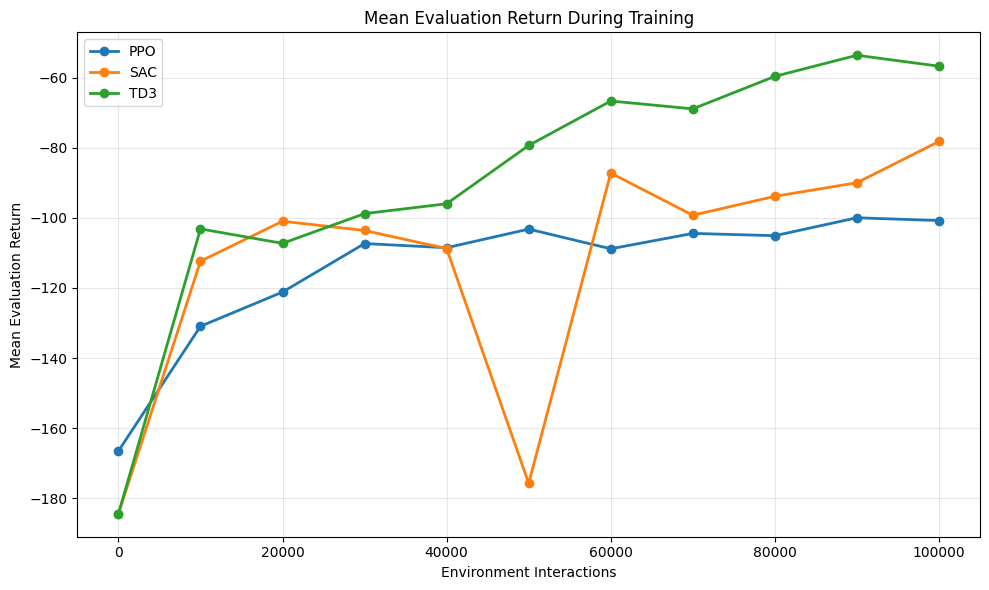

In [17]:
plt.figure(figsize=(10, 6))
for algorithm_name in algorithms:
    algorithm_data = learning_results_df[learning_results_df["algorithm"] == algorithm_name]
    plt.plot(
        algorithm_data["steps"],
        algorithm_data["mean_return"],
        marker="o",
        linewidth=2,
        label=algorithm_name
    )

plt.xlabel("Environment Interactions")
plt.ylabel("Mean Evaluation Return")
plt.title("Mean Evaluation Return During Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "mean_evaluation_return.pdf"),format="pdf",bbox_inches="tight")
plt.show()

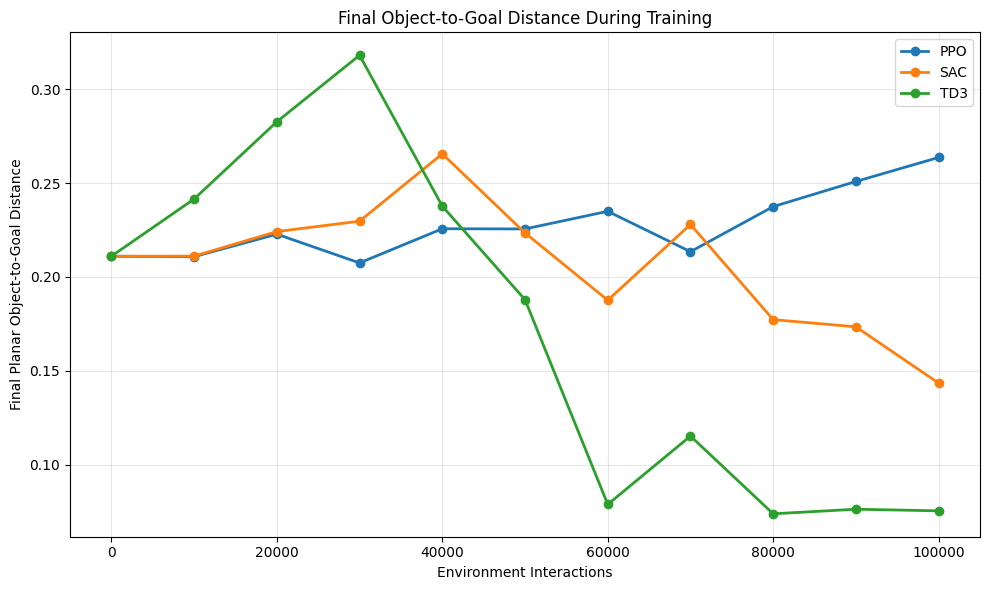

In [30]:
plt.figure(figsize=(10, 6))
for algorithm_name in algorithms:
    algorithm_data = learning_results_df[learning_results_df["algorithm"] == algorithm_name]
    plt.plot(
        algorithm_data["steps"],
        algorithm_data["mean_object_goal_distance"],
        marker="o",
        linewidth=2,
        label=algorithm_name
    )
plt.xlabel("Environment Interactions")
plt.ylabel("Final Planar Object-to-Goal Distance")
plt.title("Final Object-to-Goal Distance During Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "object_goal_distance.pdf"),format="pdf",bbox_inches="tight")
plt.show()

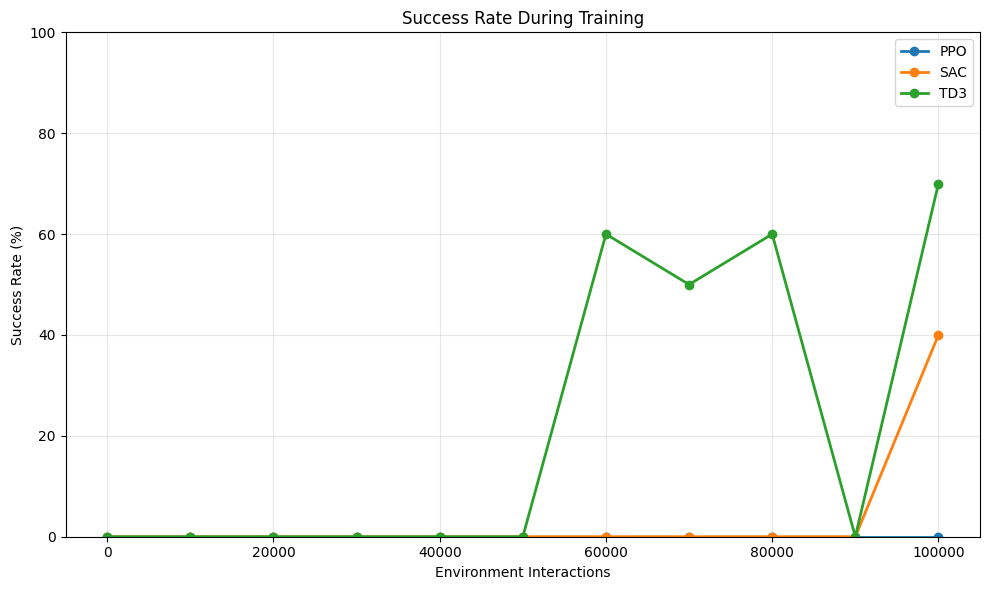

In [18]:
plt.figure(figsize=(10, 6))
for algorithm_name in algorithms:
    algorithm_data = learning_results_df[learning_results_df["algorithm"] == algorithm_name]
    plt.plot(
        algorithm_data["steps"],
        algorithm_data["success_rate"],
        marker="o",
        linewidth=2,
        label=algorithm_name
    )
plt.xlabel("Environment Interactions")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate During Training")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "success_rate.pdf"),format="pdf",bbox_inches="tight")
plt.show()

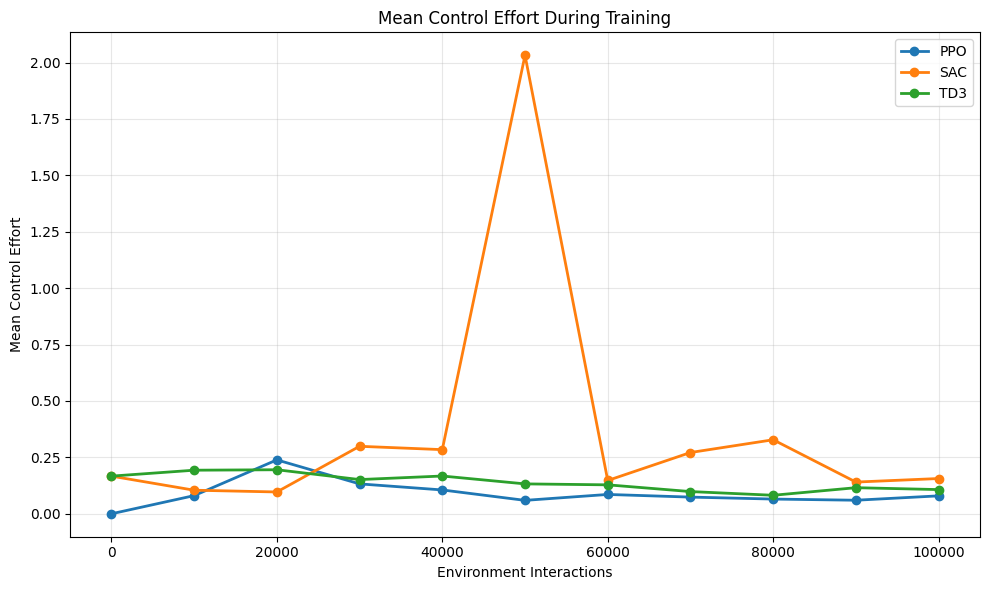

In [19]:
plt.figure(figsize=(10, 6))
for algorithm_name in algorithms:
    algorithm_data = learning_results_df[learning_results_df["algorithm"] == algorithm_name]
    plt.plot(
        algorithm_data["steps"],
        algorithm_data["mean_control_effort"],
        marker="o",
        linewidth=2,
        label=algorithm_name
    )
plt.xlabel("Environment Interactions")
plt.ylabel("Mean Control Effort")
plt.title("Mean Control Effort During Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "mean_control_effort.pdf"),format="pdf",bbox_inches="tight")
plt.show()

In [20]:
all_final_episode_results = []
final_summaries = []

for algorithm_name in algorithms:
    summary, episodes_df = evaluate_model(
        model=trained_models[algorithm_name],
        number_of_episodes=FINAL_EVAL_EPISODES,
        # Different seeds from checkpoint evaluation
        seed_offset=50_000
    )
    episodes_df["algorithm"] = algorithm_name
    all_final_episode_results.append(episodes_df)
    summary["algorithm"] = algorithm_name
    final_summaries.append(summary)

final_episodes_df = pd.concat(all_final_episode_results,ignore_index=True)
final_summary_df = pd.DataFrame(final_summaries)
final_episodes_df.to_csv(os.path.join(RESULTS_DIR,"final_20_episodes.csv"),index=False)
final_episodes_df.head()

,return,object_goal_distance,success,fingertip_object_distance,control_effort,episode_steps,episode,algorithm
0,-131.091629,0.413915,0,0.131096,0.086774,300,1,PPO
1,-133.425202,0.322407,0,0.221594,0.080033,300,2,PPO
2,-90.674718,0.262465,0,0.145536,0.078334,300,3,PPO
3,-105.115144,0.320576,0,0.111529,0.082361,300,4,PPO
4,-137.699097,0.445636,0,0.146959,0.087027,300,5,PPO


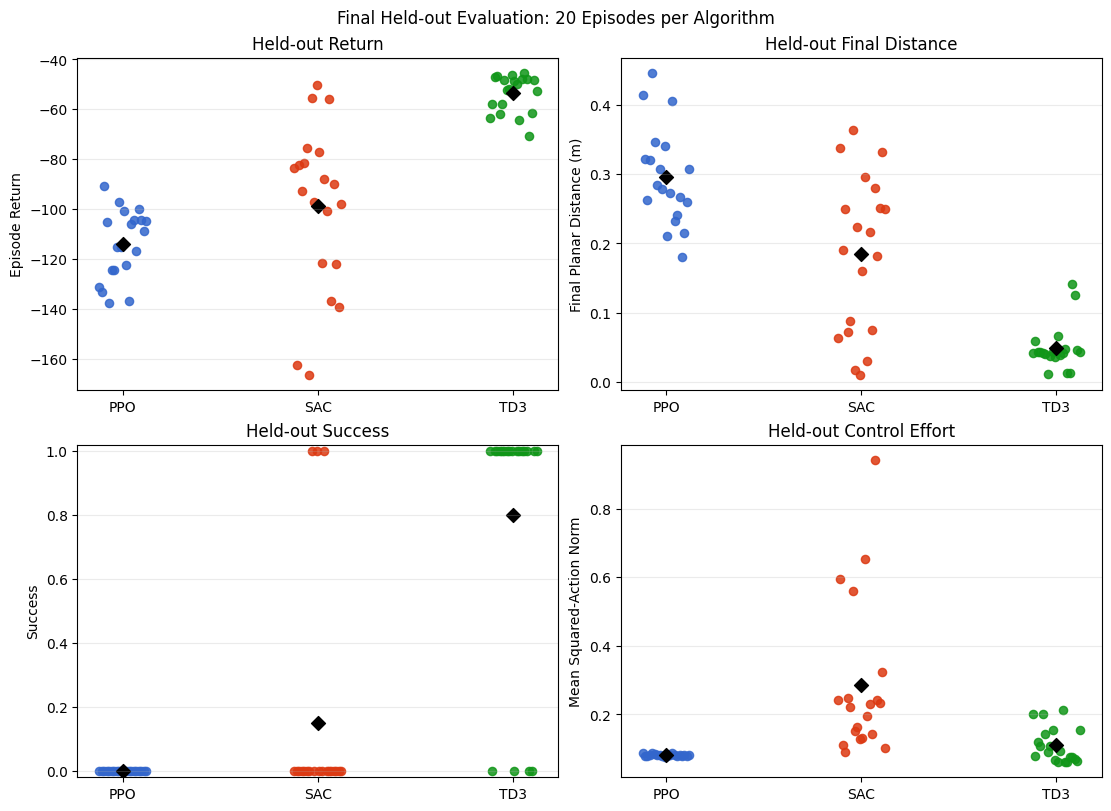

In [21]:
fig, axes = plt.subplots(2,2,figsize=(11, 8),constrained_layout=True)
heldout_plots = [
    ("return", "Held-out Return", "Episode Return"),
    ("object_goal_distance","Held-out Final Distance","Final Planar Distance (m)"),
    ("success", "Held-out Success", "Success"),
    ("control_effort","Held-out Control Effort","Mean Squared-Action Norm")
]
colors = {
    "PPO": "#3366cc",
    "SAC": "#dc3912",
    "TD3": "#109618"
}
for axis, (column, title, ylabel) in zip(axes.flat,heldout_plots):
    for algorithm_index, algorithm_name in enumerate(algorithms):
        values = final_episodes_df.loc[final_episodes_df["algorithm"] == algorithm_name,column].to_numpy()
        # Slight horizontal separation to display all 20 episodes
        jitter = np.linspace(-0.12, 0.12, len(values))
        axis.scatter(
            algorithm_index + jitter, values,
            color=colors[algorithm_name],
            s=35,alpha=0.85)

        # Black diamond represents the mean
        axis.scatter(algorithm_index,values.mean(),color="black",marker="D",s=50)

    axis.set_xticks(range(len(algorithms)),algorithms)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.grid(axis="y", alpha=0.25)

axes[1, 0].set_ylim(-0.02, 1.02)

fig.suptitle("Final Held-out Evaluation: 20 Episodes per Algorithm")

plt.savefig(os.path.join(PLOTS_DIR, "heldout_20_episodes.pdf"),format="pdf",bbox_inches="tight")
plt.show()

In [23]:
normalized_auc_results = {}

for algorithm_name in algorithms:
    algorithm_data = (learning_results_df[learning_results_df["algorithm"] == algorithm_name].sort_values("steps"))
    steps = algorithm_data["steps"].to_numpy()
    returns = algorithm_data["mean_return"].to_numpy()
    normalized_auc = (np.trapezoid(returns, steps)/ TOTAL_TIMESTEPS)
    normalized_auc_results[algorithm_name] = normalized_auc

normalized_auc_results

{'PPO': np.float64(-112.33652738945929),
 'SAC': np.float64(-110.33100946323417),
 'TD3': np.float64(-85.42286743272135)}

In [24]:
summary_rows = []
for _, row in final_summary_df.iterrows():
    algorithm_name = row["algorithm"]
    summary_rows.append({
        "Algorithm": algorithm_name,
        "Evaluation Return (Mean ± Std)":
            f"{row['mean_return']:.2f} ± "
            f"{row['std_return']:.2f}",

        "Final Planar Distance (Mean ± Std)":
            f"{row['mean_object_goal_distance']:.4f} ± "
            f"{row['std_object_goal_distance']:.4f}",

        "Success Rate (%)":
            round(row["success_rate"], 2),

        "Fingertip-to-Object Distance (Mean ± Std)":
            f"{row['mean_fingertip_object_distance']:.4f} ± "
            f"{row['std_fingertip_object_distance']:.4f}",

        "Control Effort (Mean ± Std)":
            f"{row['mean_control_effort']:.4f} ± "
            f"{row['std_control_effort']:.4f}",

        "Normalized Return AUC": round(normalized_auc_results[algorithm_name],4)
    })

summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(os.path.join(RESULTS_DIR,"final_summary_table.csv"),index=False)
summary_table

,Algorithm,Evaluation Return (Mean ± Std),Final Planar Distance (Mean ± Std),Success Rate (%),Fingertip-to-Object Distance (Mean ± Std),Control Effort (Mean ± Std),Normalized Return AUC
0,PPO,-114.01 ± 13.92,0.2957 ± 0.0699,0.0,0.1851 ± 0.0496,0.0816 ± 0.0029,-112.3365
1,SAC,-98.85 ± 33.23,0.1843 ± 0.1137,15.0,0.1656 ± 0.0656,0.2852 ± 0.2257,-110.3310
2,TD3,-53.59 ± 7.46,0.0488 ± 0.0320,80.0,0.1050 ± 0.0096,0.1101 ± 0.0512,-85.4229


In [25]:
ranking_df = final_summary_df.copy()
# Higher values are better
ranking_df["return_rank"] = ranking_df["mean_return"].rank(ascending=False)
ranking_df["success_rank"] = ranking_df["success_rate"].rank(ascending=False)

# Lower values are better
ranking_df["distance_rank"] = ranking_df["mean_object_goal_distance"].rank(ascending=True)
ranking_df["effort_rank"] = ranking_df["mean_control_effort"].rank(ascending=True)

ranking_df["fingertip_rank"] = ranking_df["mean_fingertip_object_distance"].rank(ascending=True)
ranking_df["auc_rank"] = ranking_df["algorithm"].map(lambda name: normalized_auc_results[name]).rank(ascending=False)

ranking_df["overall_rank_score"] = (
    ranking_df["return_rank"] +
    ranking_df["success_rank"] +
    ranking_df["distance_rank"] +
    ranking_df["effort_rank"] +
    ranking_df["fingertip_rank"] +
    ranking_df["auc_rank"]
)
ranking_df = ranking_df.sort_values("overall_rank_score")
best_algorithm = ranking_df.iloc[0]["algorithm"]
print("Best overall controller:", best_algorithm)
ranking_df[
    [
        "algorithm",
        "return_rank",
        "success_rank",
        "distance_rank",
        "effort_rank",
        "fingertip_rank",
        "auc_rank",
        "overall_rank_score"
    ]
]

Best overall controller: TD3


,algorithm,return_rank,success_rank,distance_rank,effort_rank,fingertip_rank,auc_rank,overall_rank_score
2,TD3,1.0,1.0,1.0,2.0,1.0,1.0,7.0
1,SAC,2.0,2.0,2.0,3.0,2.0,2.0,13.0
0,PPO,3.0,3.0,3.0,1.0,3.0,3.0,16.0


In [26]:
import time

best_model = trained_models[best_algorithm]

view_env = gym.make("Pusher-v5",
    max_episode_steps=MAX_EPISODE_STEPS,
    render_mode="human"
)

observation, info = view_env.reset(seed=70_000)

terminated = False
truncated = False
total_reward = 0.0

while not (terminated or truncated):

    action, _ = best_model.predict(observation,deterministic=True)
    action = np.asarray(action,dtype=np.float32).reshape(view_env.action_space.shape)
    observation, reward, terminated, truncated, info = (view_env.step(action))
    total_reward += reward
    time.sleep(0.03)

#time.sleep(3)
view_env.close()

print("Displayed algorithm:", best_algorithm)
print("Episode return:", total_reward)

Displayed algorithm: TD3
Episode return: -43.78326945109754


In [27]:
import imageio.v2 as imageio
from IPython.display import Video, display

# Select the best controller found by the ranking
video_model = trained_models[best_algorithm]

# Create an environment that returns video frames
video_env = gym.make(
    "Pusher-v5",
    max_episode_steps=MAX_EPISODE_STEPS,
    render_mode="rgb_array"
)

observation, info = video_env.reset(seed=70_000)

terminated = False
truncated = False
video_total_reward = 0.0
frames = []

while not (terminated or truncated):

    # Capture the current frame
    frames.append(video_env.render())

    action, _ = video_model.predict(
        observation,
        deterministic=True
    )

    action = np.asarray(
        action,
        dtype=np.float32
    ).reshape(video_env.action_space.shape)

    observation, reward, terminated, truncated, info = video_env.step(action)

    video_total_reward += float(reward)

# Capture the final frame
frames.append(video_env.render())

video_env.close()

# Save the video inside the experiment folder
video_path = os.path.join(
    RESULTS_DIR,
    "best_controller_final_test.mp4"
)

with imageio.get_writer(
    video_path,
    format="FFMPEG",
    mode="I",
    fps=30,
    codec="libx264",
    quality=8
) as writer:

    for frame in frames:
        writer.append_data(frame)

print("Saved video:", os.path.abspath(video_path))
print("Recorded algorithm:", best_algorithm)
print("Episode return:", video_total_reward)

display(Video(video_path, embed=True))

Saved video: c:\Users\NTC\Downloads\Modeling Code\pusher_results_300_default_reward\best_controller_final_test.mp4
Recorded algorithm: TD3
Episode return: -43.78326945109754
